<p align="center">
• <a href="https://mayzune.com/"><strong>May Zune</strong></a> •
<a href="https://github.com/hellomayzune"><strong>GitHub</strong></a> •
<a href="https://orcid.org/0000-0003-0282-2633"><strong>ORCID</strong></a> •
<a href="https://scholar.google.com/citations?user=LmP8B_4AAAAJ&hl=en"><strong>Google Scholar</strong></a> •
<a href="https://www.researchgate.net/profile/May-Zune"><strong>ResearchGate</strong></a> •
<a href="https://www.linkedin.com/in/mayzune//"><strong>Linkedin</strong></a> •
</p>

# EPC-Based Energy Consumption Prediction Using Logistic Regression

## Logistic Regression Pipeline

The notebook builds a **Logistic Regression classification model** to predict whether a property has **high or low energy consumption**.

1. **Load data** – Reads the cleaned EPC Sheffield dataset.
2. **Prepare target** – Uses the median `energy_consumption_current` as the threshold to create a binary target:
   - `0` = Low energy consumption
   - `1` = High energy consumption
3. **Remove columns** – Drops identifiers and variables not used as predictors, including postcode and the original energy-consumption target.
4. **Preprocess features**:
   - Numerical features: median imputation + standardisation.
   - Categorical features: most-frequent imputation + one-hot encoding.
5. **Split data** – Uses an 80/20 stratified train/test split with a fixed random seed.
6. **Train model** – Combines preprocessing and Logistic Regression in a Scikit-learn pipeline and fits it to the training data.
7. **Generate predictions** – Produces predicted classes and probabilities for the test set.
8. **Evaluate performance** – Assesses the model using accuracy, confusion matrix, ROC-AUC, ROC curve, precision-recall curve, and average precision.
9. **Interpret model** – Examines Logistic Regression coefficients to identify the features most strongly associated with higher or lower predicted energy consumption.

## Limitations

- The continuous energy-consumption target is simplified into a binary high/low classification using the median, losing information about actual consumption levels.
- The median threshold is dataset-dependent and may not represent a meaningful practical energy-consumption boundary.
- Only Logistic Regression is evaluated, with no comparison against alternative machine-learning models.
- Model performance is based on a single 80/20 train-test split rather than cross-validation.
- The reported performance may not generalise to other regions, datasets, or future EPC records.
- No systematic hyperparameter tuning is performed.
- Feature interpretation is primarily based on Logistic Regression coefficients and may not capture complex or non-linear relationships.

## Applicability to Real-World Studies

The model can support real-world energy-efficiency studies by:

- **Identifying high-consumption properties** for further investigation.
- **Supporting targeted interventions**, such as prioritising properties for energy-efficiency improvements.
- **Enabling large-scale EPC analysis** by automatically classifying properties into high- and low-consumption groups.
- **Providing decision support** through predicted probabilities and model outputs.
- **Supporting interpretation** by identifying property characteristics associated with higher or lower predicted energy consumption.

However, the model should be treated as a **decision-support and research tool**, rather than a standalone basis for interventions. Further validation using independent datasets, different geographic areas, and real-world data would be required before operational use.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    roc_curve, 
    auc, 
    precision_recall_curve, 
    average_precision_score
)

In [2]:
# Set style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11})

In [3]:
# 1. Load data
df = pd.read_csv('EPC_Sheffield_20260414-clean.csv')

# Drop specified columns
X = df.drop(columns=['certificate_number', 'postcode', 'constituency_label', 'constituency', 'energy_consumption_current'])

# Define binary classification target: High (> Median) vs Low (<= Median)
median_val = df['energy_consumption_current'].median()
y_binary = (df['energy_consumption_current'] > median_val).astype(int)

# Identify numerical and categorical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Build ColumnTransformer
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [4]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42, stratify=y_binary)

# Build and fit Logistic Regression Pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

model_pipeline.fit(X_train, y_train)

# Predictions and probabilities
y_pred = model_pipeline.predict(X_test)
y_probs = model_pipeline.predict_proba(X_test)[:, 1]

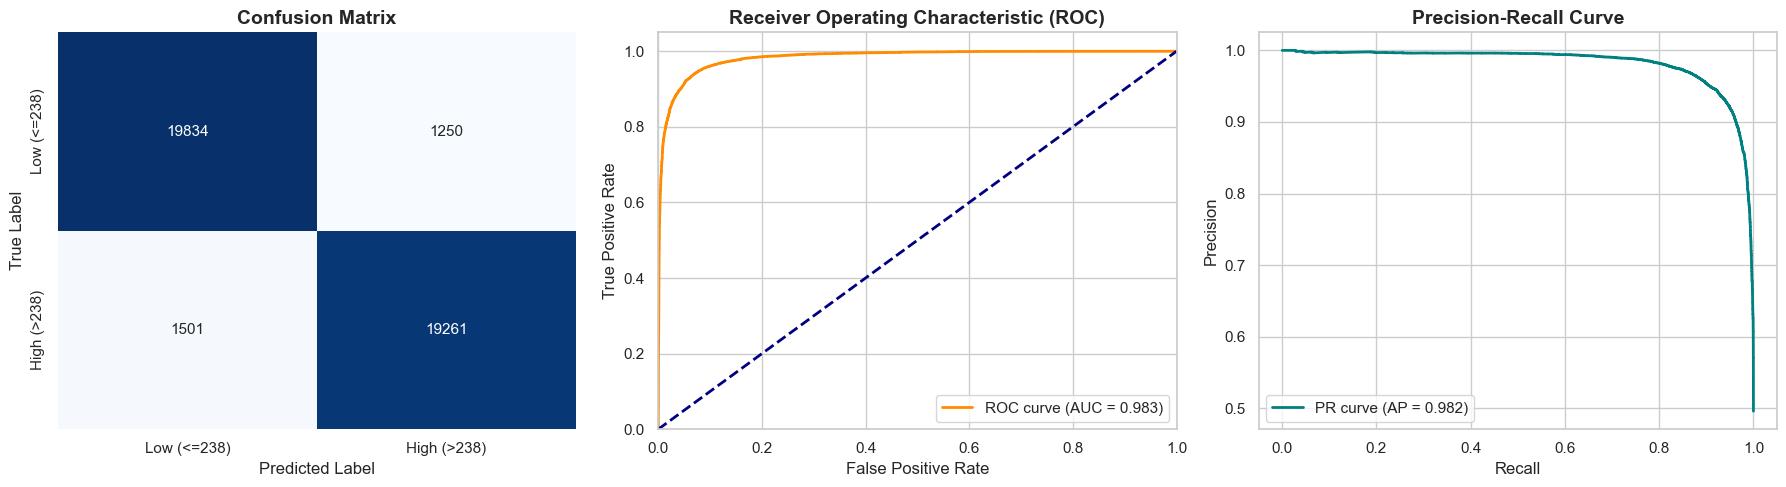

In [5]:
# ---------------------------------------------------------
# VISUALIZATION 1: Confusion Matrix & ROC Curve & Precision-Recall Curve
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['Low (<=238)', 'High (>238)'], yticklabels=['Low (<=238)', 'High (>238)'])
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic (ROC)', fontsize=14, fontweight='bold')
axes[1].legend(loc="lower right")

# 3. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_probs)
ap_score = average_precision_score(y_test, y_probs)
axes[2].plot(recall, precision, color='teal', lw=2, label=f'PR curve (AP = {ap_score:.3f})')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[2].legend(loc="lower left")

plt.tight_layout()

# plt.savefig('logistic_regression_eval_metrics.png', dpi=300)
# plt.close()

Evaluation Visualizations Generated Successfully.
Accuracy: 0.9343
ROC AUC: 0.9829


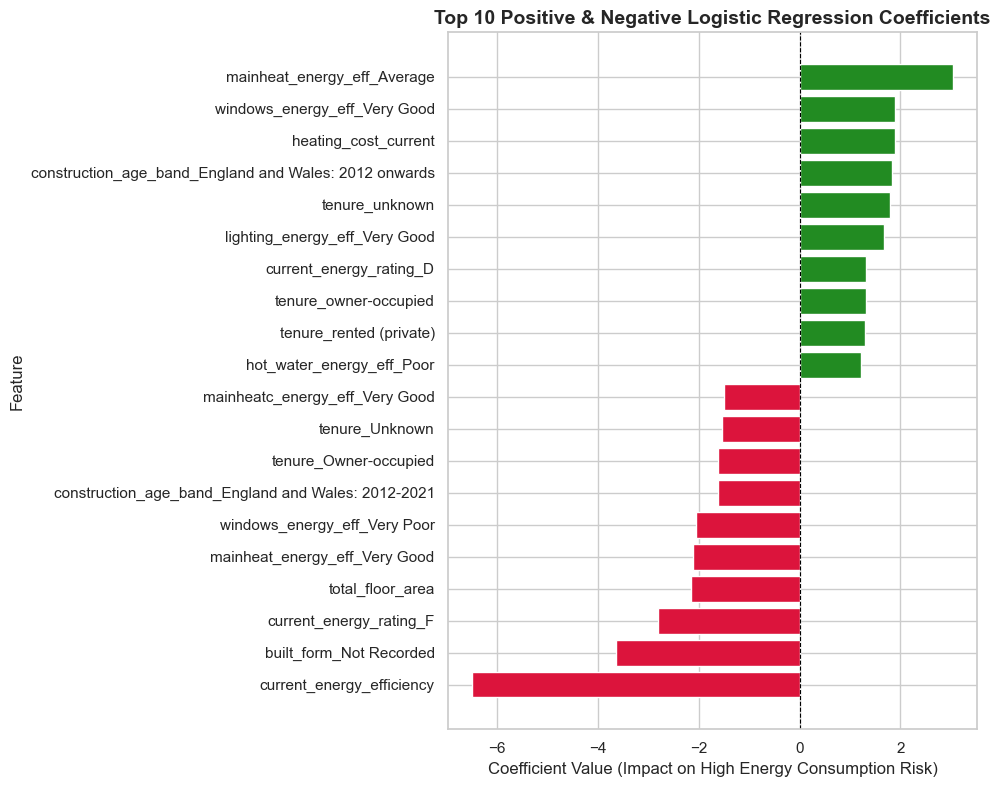

In [6]:
# ---------------------------------------------------------
# VISUALIZATION 2: Feature Importance (Top Positive & Negative Coefficients)
# ---------------------------------------------------------
# Extract feature names after One Hot Encoding
ohe = model_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_feature_names = ohe.get_feature_names_out(categorical_cols).tolist()
all_feature_names = numeric_cols + cat_feature_names

coefficients = model_pipeline.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

top_pos = coef_df.head(10)
top_neg = coef_df.tail(10)
top_coefs = pd.concat([top_pos, top_neg]).sort_values(by='Coefficient')

plt.figure(figsize=(10, 8))
colors = ['crimson' if c < 0 else 'forestgreen' for c in top_coefs['Coefficient']]
plt.barh(top_coefs['Feature'], top_coefs['Coefficient'], color=colors)
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Top 10 Positive & Negative Logistic Regression Coefficients', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient Value (Impact on High Energy Consumption Risk)')
plt.ylabel('Feature')
plt.tight_layout()

# plt.savefig('logistic_regression_feature_importance.png', dpi=300)
# plt.close()

print("Evaluation Visualizations Generated Successfully.")
print(f"Accuracy: {model_pipeline.score(X_test, y_test):.4f}")
print(f"ROC AUC: {roc_auc:.4f}")